In [1]:
# ─────────────────────────────────────────────
# CELL 1 — Dependencies
# ─────────────────────────────────────────────
import sys
!{sys.executable} -m pip install -q \
    "diffusers>=0.25.0" transformers accelerate xformers \
    scikit-image lpips clean-fid opencv-python-headless
print("Dependencies ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 38.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.0 MB/s eta 0:00:00
Dependencies ready


In [2]:
# ─────────────────────────────────────────────
# CELL 2 — Config & Paths
# ─────────────────────────────────────────────
import random
from pathlib import Path
import numpy as np
import pandas as pd
import torch

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATASET_ROOT = Path("/kaggle/input/datasets/dangvy1507/occlusion")
SYNTH_DIR    = DATASET_ROOT / "synthetic_occ"
GT_DIR       = SYNTH_DIR / "x_gt"
OCC_DIR      = SYNTH_DIR / "x_occ"
MASK_DIR     = SYNTH_DIR / "masks"
META_CSV     = SYNTH_DIR / "metadata_synthetic_occ.csv"

CN_DIR        = Path("/kaggle/working/controlnet_sd")
PRED_DIR      = CN_DIR / "x_hat"
EVAL_GT_DIR   = CN_DIR / "eval_gt_200"
EVAL_PRED_DIR = CN_DIR / "eval_pred_200"
REPORT_DIR    = CN_DIR / "reports"
for d in [PRED_DIR, EVAL_GT_DIR, EVAL_PRED_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE   = torch.float16 if DEVICE == "cuda" else torch.float32

SD_MODEL_ID = "runwayml/stable-diffusion-inpainting"
CN_MODEL_ID = "lllyasviel/control_v11p_sd15_canny"

PROMPT     = "a car, realistic, high quality, detailed"
NEG_PROMPT = "blurry, distorted, artifacts"
NUM_STEPS  = 20
GUIDANCE   = 7.5
TEST_SIZE  = 200

CN_SCALE_GRID        = [0.15, 0.25, 0.35, 0.50, 0.65, 0.80]
CN_SCALE_GRID_SAMPLE = 30
CANNY_LOW      = 80
CANNY_HIGH     = 150
MASK_DILATE_PX = 5

meta = pd.read_csv(META_CSV)
print(f"Meta rows  : {len(meta):,}")
print(f"Device     : {DEVICE}")
print(f"SD model   : {SD_MODEL_ID}")
print(f"ControlNet : {CN_MODEL_ID}")

Meta rows  : 11,254
Device     : cuda
SD model   : runwayml/stable-diffusion-inpainting
ControlNet : lllyasviel/control_v11p_sd15_canny


In [3]:
# ─────────────────────────────────────────────
# CELL 3 — Load ControlNet + SD Inpainting pipeline
# Dùng built-in StableDiffusionControlNetInpaintPipeline (diffusers >= 0.19)
# thay vì custom pipeline → tương thích tốt hơn, xử lý đúng 9-channel UNet.
# ─────────────────────────────────────────────
import cv2
from PIL import Image
from diffusers import (
    StableDiffusionControlNetInpaintPipeline,
    ControlNetModel,
    DPMSolverMultistepScheduler,
)

print("Loading ControlNet ...")
controlnet = ControlNetModel.from_pretrained(CN_MODEL_ID, torch_dtype=DTYPE)

print("Loading SD Inpainting + ControlNet pipeline ...")
pipe = StableDiffusionControlNetInpaintPipeline.from_pretrained(
    SD_MODEL_ID,
    controlnet=controlnet,
    torch_dtype=DTYPE,
    safety_checker=None,
    requires_safety_checker=False,
)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to(DEVICE)

xformers_ok = False
try:
    pipe.enable_xformers_memory_efficient_attention()
    xformers_ok = True
    print("xFormers: enabled")
except Exception:
    pipe.enable_attention_slicing("auto")
    print("xFormers: fallback to attention slicing")

pipe.vae.enable_slicing()
print(f"Pipeline loaded | Scheduler: {pipe.scheduler.__class__.__name__} | xFormers: {xformers_ok}")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading ControlNet ...


config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

Loading SD Inpainting + ControlNet pipeline ...


...

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--run

xFormers: enabled
Pipeline loaded | Scheduler: DPMSolverMultistepScheduler | xFormers: True


In [4]:
# ─────────────────────────────────────────────
# CELL 4 — Mask-aware Canny extraction + inpaint wrapper
# ─────────────────────────────────────────────

def extract_canny_masked(
    image_pil: Image.Image,
    mask_pil: Image.Image,
    low: int = CANNY_LOW,
    high: int = CANNY_HIGH,
    dilate_px: int = MASK_DILATE_PX,
) -> Image.Image:
    """
    Trích Canny từ x_occ, sau đó xoá mọi cạnh nằm trong vùng mask
    (+ margin dilate để loại bỏ cạnh occluder sát biên).
    ControlNet chỉ nhận cấu trúc cạnh từ phần xe nhìn thấy được,
    không bị nhiễu bởi biên của vật che.
    """
    img = np.array(image_pil.convert("RGB"))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, low, high)

    mask_np = np.array(mask_pil.convert("L"))
    if dilate_px > 0:
        kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE, (dilate_px * 2 + 1, dilate_px * 2 + 1)
        )
        mask_np = cv2.dilate(mask_np, kernel, iterations=1)
    edges[mask_np > 127] = 0

    return Image.fromarray(np.stack([edges] * 3, axis=2))


def inpaint_cn(
    image: Image.Image,
    mask: Image.Image,
    prompt: str,
    cn_scale: float = 0.35,
    seed: int = SEED,
) -> Image.Image:
    canny = extract_canny_masked(image, mask)
    generator = torch.Generator(device=DEVICE).manual_seed(seed)
    with torch.autocast("cuda"):
        out = pipe(
            prompt=prompt,
            negative_prompt=NEG_PROMPT,
            image=image,
            control_image=canny,
            mask_image=mask,
            num_inference_steps=NUM_STEPS,
            guidance_scale=GUIDANCE,
            controlnet_conditioning_scale=cn_scale,
            generator=generator,
        ).images[0]
    torch.cuda.empty_cache()
    return out

print("extract_canny_masked + inpaint_cn defined")

extract_canny_masked + inpaint_cn defined


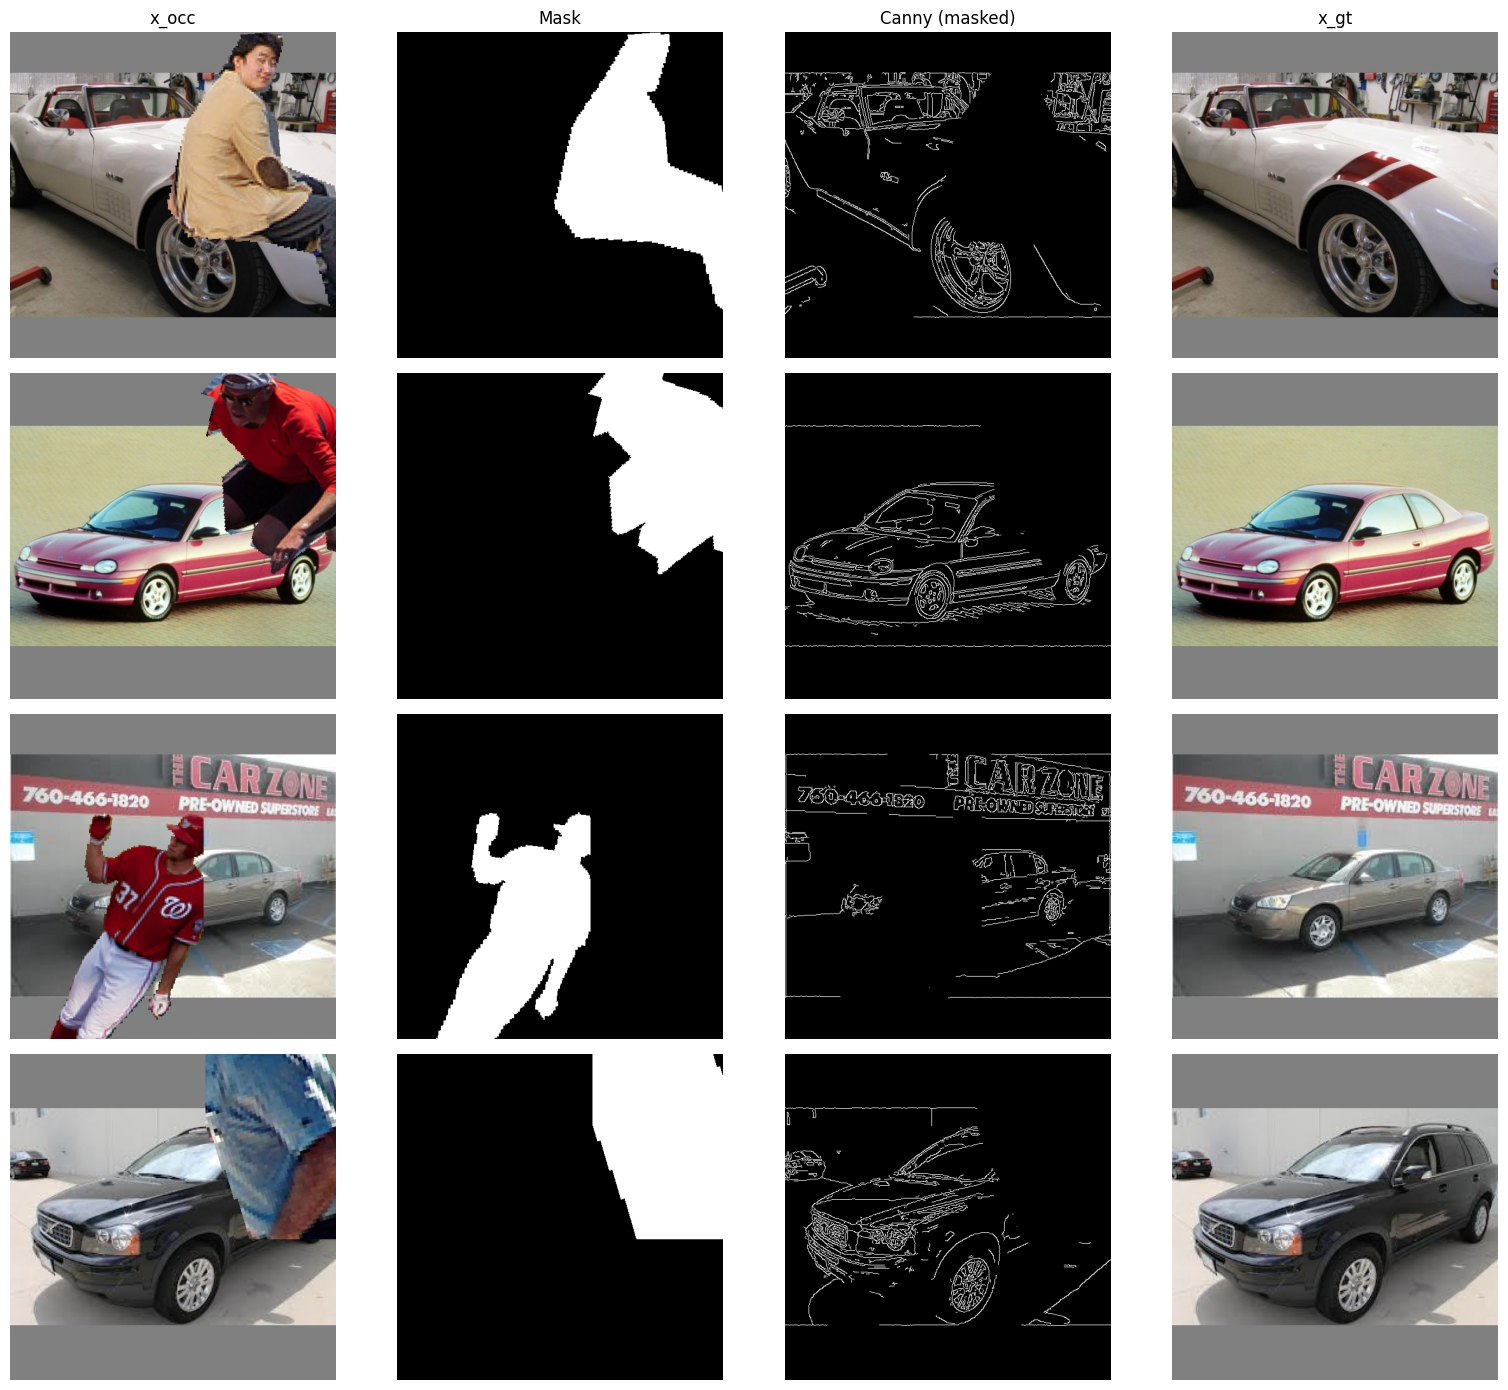

In [5]:
# ─────────────────────────────────────────────
# CELL 5 — Visualize Canny (mask-aware) trên 4 sample
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt

meta_sample = meta.sample(4, random_state=SEED).reset_index(drop=True)
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
for i, row in meta_sample.iterrows():
    occ = Image.open(OCC_DIR / row["x_occ"]).convert("RGB").resize((512, 512))
    msk = Image.open(MASK_DIR / f"{row['stem']}.png").convert("L").resize((512, 512))
    gt  = Image.open(GT_DIR  / row["x_gt"]).convert("RGB").resize((512, 512))
    can = extract_canny_masked(occ, msk)
    if i == 0:
        axes[i, 0].set_title("x_occ")
        axes[i, 1].set_title("Mask")
        axes[i, 2].set_title("Canny (masked)")
        axes[i, 3].set_title("x_gt")
    axes[i, 0].imshow(occ)
    axes[i, 1].imshow(msk, cmap="gray")
    axes[i, 2].imshow(can)
    axes[i, 3].imshow(gt)
    for ax in axes[i]:
        ax.axis("off")
plt.tight_layout()
plt.show()

In [6]:
# ─────────────────────────────────────────────
# CELL 6 — Grid search cn_scale
# ─────────────────────────────────────────────
from tqdm.auto import tqdm
from skimage.metrics import structural_similarity as ssim_fn
import lpips as lpips_lib

lpips_model = lpips_lib.LPIPS(net="alex").to(DEVICE)
lpips_model.eval()


def masked_ssim(gt, pred, mask01):
    gt_f  = gt.astype(np.float32) / 255.0
    pr_f  = pred.astype(np.float32) / 255.0
    _, ssim_map = ssim_fn(gt_f, pr_f, channel_axis=2, data_range=1.0, full=True)
    m = mask01.astype(bool)
    return float(ssim_map[m].mean()) if m.sum() > 0 else float(ssim_map.mean())


def masked_lpips(gt, pred, mask01):
    m    = mask01.astype(np.float32)[..., None]
    gt_m = (gt.astype(np.float32) * m).astype(np.uint8)
    pr_m = (pred.astype(np.float32) * m).astype(np.uint8)
    gt_t = torch.from_numpy(gt_m).permute(2, 0, 1).unsqueeze(0).float() / 127.5 - 1.0
    pr_t = torch.from_numpy(pr_m).permute(2, 0, 1).unsqueeze(0).float() / 127.5 - 1.0
    with torch.no_grad():
        return float(lpips_model(gt_t.to(DEVICE), pr_t.to(DEVICE)).item())


grid_sample = meta.sample(CN_SCALE_GRID_SAMPLE, random_state=SEED).reset_index(drop=True)
grid_res    = []

for scale in CN_SCALE_GRID:
    ss, lp = [], []
    for _, r in tqdm(grid_sample.iterrows(), total=len(grid_sample),
                     desc=f"scale={scale}"):
        occ  = Image.open(OCC_DIR  / r["x_occ"]).convert("RGB").resize((512, 512))
        msk  = Image.open(MASK_DIR / f"{r['stem']}.png").convert("L").resize((512, 512))
        gt   = Image.open(GT_DIR   / r["x_gt"]).convert("RGB").resize((512, 512))
        pred = inpaint_cn(occ, msk, PROMPT, cn_scale=scale, seed=SEED)

        gt_np = np.array(gt)
        pr_np = np.array(pred)
        mk_np = cv2.imread(str(MASK_DIR / f"{r['stem']}.png"), cv2.IMREAD_GRAYSCALE)
        mk01  = (cv2.resize(mk_np, (512, 512)) > 127).astype(np.uint8)
        ss.append(masked_ssim(gt_np, pr_np, mk01))
        lp.append(masked_lpips(gt_np, pr_np, mk01))

    grid_res.append({
        "cn_scale": scale,
        "ssim_mean": float(np.mean(ss)),
        "lpips_mean": float(np.mean(lp)),
    })
    print(f"  scale={scale}  SSIM={np.mean(ss):.4f} | LPIPS={np.mean(lp):.4f}")

grid_df_result = pd.DataFrame(grid_res)
BEST_SCALE = float(grid_df_result.loc[grid_df_result["lpips_mean"].idxmin(), "cn_scale"])
print(f"\nBest scale (by LPIPS): {BEST_SCALE}")
grid_df_result.to_csv(REPORT_DIR / "grid_search.csv", index=False)
print(grid_df_result.to_string(index=False))

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth



  0%|          | 0.00/233M [00:00<?, ?B/s]
  4%|▎         | 8.62M/233M [00:00<00:02, 90.2MB/s]
 13%|█▎        | 29.6M/233M [00:00<00:01, 166MB/s] 
 22%|██▏       | 51.0M/233M [00:00<00:00, 193MB/s]
 31%|███       | 72.2M/233M [00:00<00:00, 204MB/s]
 40%|████      | 93.9M/233M [00:00<00:00, 212MB/s]
 49%|████▉     | 115M/233M [00:00<00:00, 214MB/s] 
 58%|█████▊    | 135M/233M [00:00<00:00, 213MB/s]
 67%|██████▋   | 156M/233M [00:00<00:00, 214MB/s]
 76%|███████▌  | 177M/233M [00:00<00:00, 216MB/s]
 85%|████████▍ | 198M/233M [00:01<00:00, 216MB/s]
100%|██████████| 233M/233M [00:01<00:00, 208MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


...

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  scale=0.8  SSIM=0.4669 | LPIPS=0.0874

Best scale (by LPIPS): 0.8
 cn_scale  ssim_mean  lpips_mean
     0.15   0.447043    0.095625
     0.25   0.459948    0.092616
     0.35   0.461670    0.091799
     0.50   0.466549    0.089265
     0.65   0.463987    0.088448
     0.80   0.466933    0.087374


In [7]:
# ─────────────────────────────────────────────
# CELL 7 — Full inference 200 images + Evaluate (SSIM, LPIPS, FID)
# ─────────────────────────────────────────────
import time
from cleanfid import fid

test_df = meta.sample(TEST_SIZE, random_state=SEED).reset_index(drop=True)
pred_records = []
t0 = time.time()

for idx, r in tqdm(test_df.iterrows(), total=len(test_df), desc="Inference"):
    occ = Image.open(OCC_DIR  / r["x_occ"]).convert("RGB").resize((512, 512))
    msk = Image.open(MASK_DIR / f"{r['stem']}.png").convert("L").resize((512, 512))
    gt  = Image.open(GT_DIR   / r["x_gt"]).convert("RGB").resize((512, 512))

    pred = inpaint_cn(occ, msk, PROMPT, cn_scale=BEST_SCALE, seed=SEED)

    pred_name = f"{r['stem']}.png"
    pred.save(PRED_DIR / pred_name)
    gt.save(EVAL_GT_DIR / pred_name)
    pred.save(EVAL_PRED_DIR / pred_name)
    pred_records.append({
        "stem": r["stem"], "x_gt": r["x_gt"], "x_occ": r["x_occ"],
        "occlusion_ratio": r["occlusion_ratio"], "pred": pred_name,
    })

infer_elapsed = time.time() - t0
pred_df = pd.DataFrame(pred_records)
print(f"Inference done: {len(pred_df)} images in {infer_elapsed/60:.1f} min (cn_scale={BEST_SCALE})")

# ── Compute per-image metrics ──
metric_rows = []
for _, r in tqdm(pred_df.iterrows(), total=len(pred_df), desc="Metrics"):
    gt = cv2.cvtColor(cv2.imread(str(GT_DIR / r["x_gt"])), cv2.COLOR_BGR2RGB)
    pr = cv2.cvtColor(cv2.imread(str(PRED_DIR / r["pred"])), cv2.COLOR_BGR2RGB)
    gt = cv2.resize(gt, (512, 512))
    pr = cv2.resize(pr, (512, 512))
    mk = cv2.imread(str(MASK_DIR / f"{r['stem']}.png"), cv2.IMREAD_GRAYSCALE)
    mk = cv2.resize(mk, (512, 512))
    mk01 = (mk > 127).astype(np.uint8)
    metric_rows.append({
        "stem": r["stem"],
        "occlusion_ratio": r["occlusion_ratio"],
        "ssim": masked_ssim(gt, pr, mk01),
        "lpips": masked_lpips(gt, pr, mk01),
    })

metric_df = pd.DataFrame(metric_rows)
fid_value = fid.compute_fid(str(EVAL_GT_DIR), str(EVAL_PRED_DIR), mode="clean")

summary = {
    "config": "B_SD_CN_canny_v11_masked",
    "model": f"{SD_MODEL_ID} + {CN_MODEL_ID}",
    "scheduler": pipe.scheduler.__class__.__name__,
    "num_test_images": int(len(metric_df)),
    "prompt": PROMPT,
    "negative_prompt": NEG_PROMPT,
    "steps": int(NUM_STEPS),
    "guidance": float(GUIDANCE),
    "cn_scale": float(BEST_SCALE),
    "ssim_mean": float(metric_df["ssim"].mean()),
    "lpips_mean": float(metric_df["lpips"].mean()),
    "fid": float(fid_value),
    "inference_minutes": float(infer_elapsed / 60.0),
}

metric_df.to_csv(REPORT_DIR / "controlnet_metrics_per_image.csv", index=False)
pd.DataFrame([summary]).to_csv(REPORT_DIR / "controlnet_summary.csv", index=False)

print("=" * 60)
print(f"SSIM  (mean) : {summary['ssim_mean']:.4f}   (baseline: 0.4276)")
print(f"LPIPS (mean) : {summary['lpips_mean']:.4f}   (baseline: 0.1011)")
print(f"FID          : {summary['fid']:.2f}    (baseline: 35.67)")
print(f"cn_scale     : {BEST_SCALE}")
print("=" * 60)

Inference:   0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

compute FID between two folders
Found 200 images in the folder /kaggle/working/controlnet_sd/eval_gt_200



FID eval_gt_200 :   0%|          | 0/7 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()

FID eval_gt_200 : 100%|██████████| 7/7 [00:04<00:00,  1.50it/s]


Found 200 images in the folder /kaggle/working/controlnet_sd/eval_pred_200



FID eval_pred_200 : 100%|██████████| 7/7 [00:03<00:00,  2.15it/s]


SSIM  (mean) : 0.4700   (baseline: 0.4276)
LPIPS (mean) : 0.0911   (baseline: 0.1011)
FID          : 31.15    (baseline: 35.67)
cn_scale     : 0.8


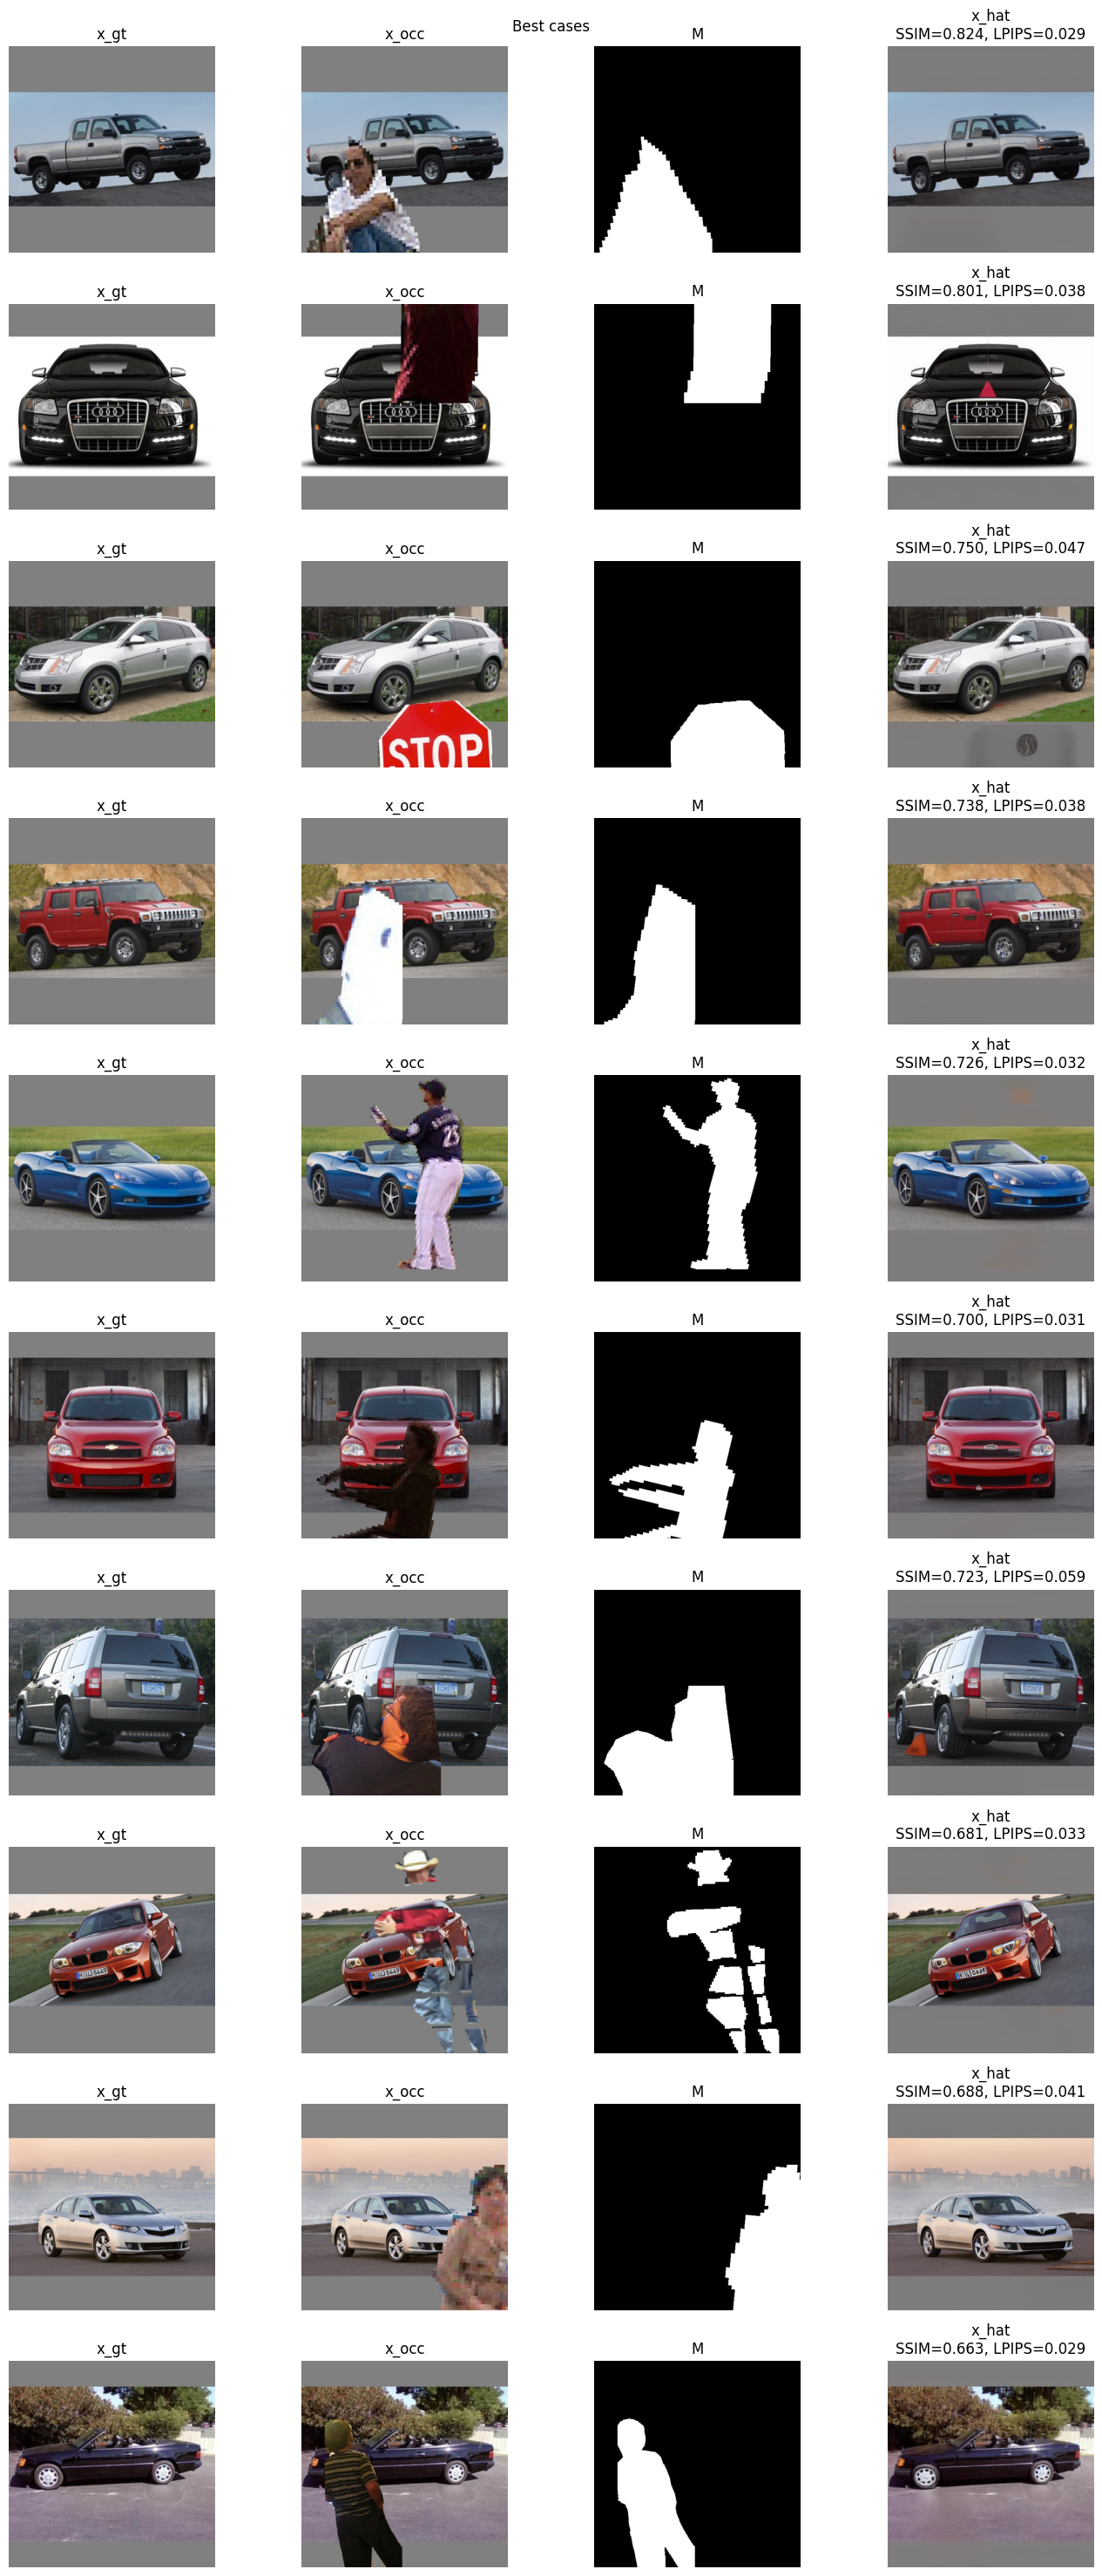

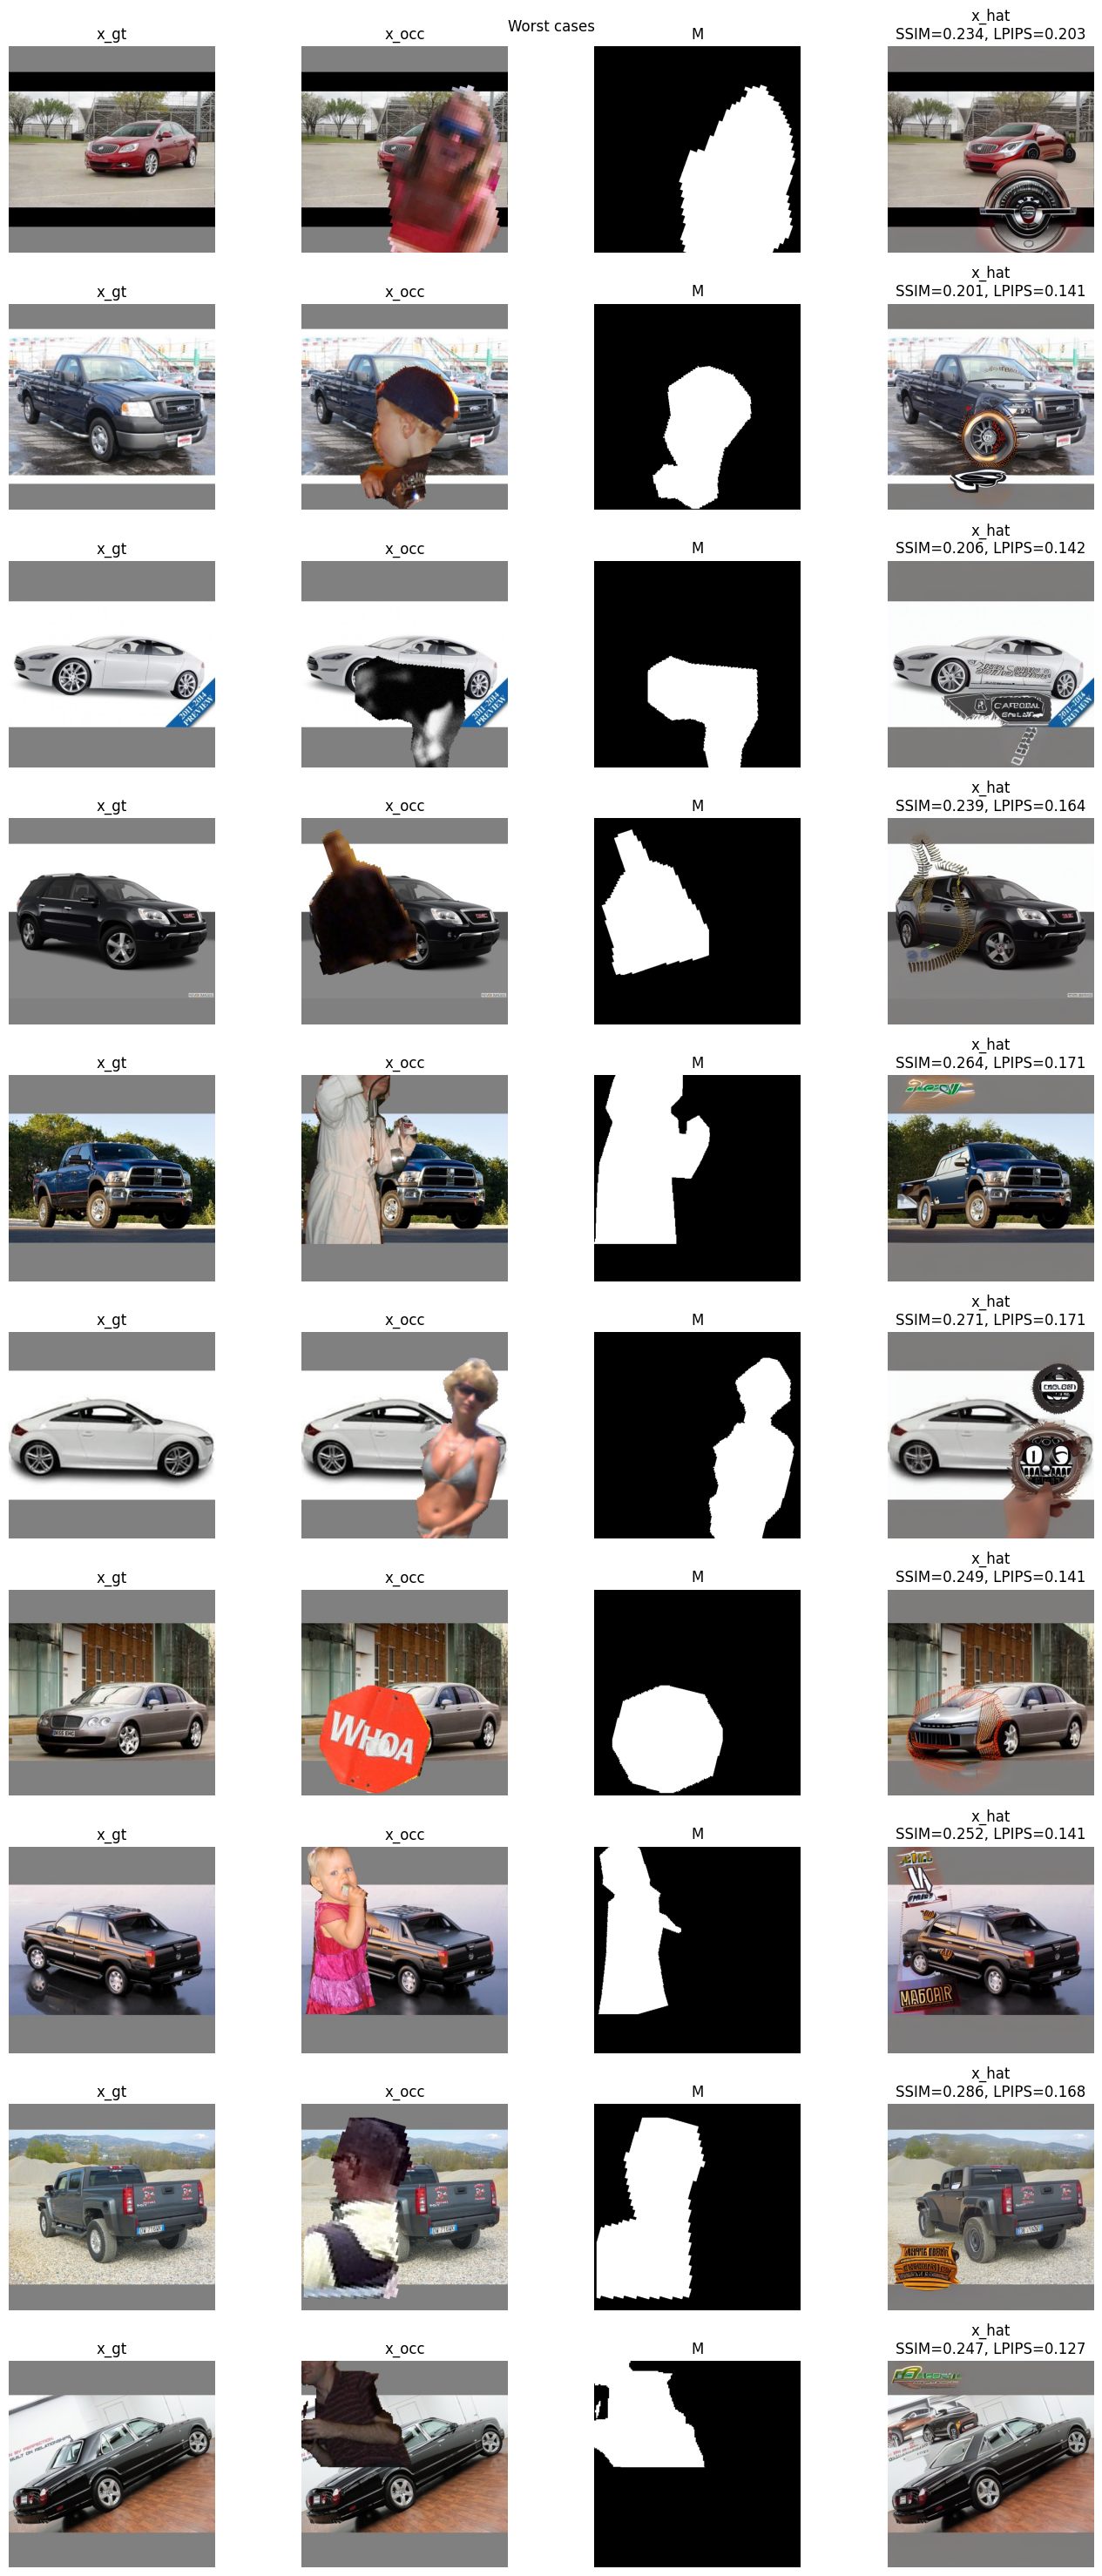

In [8]:
import matplotlib.pyplot as plt

analysis_df = metric_df.copy()
analysis_df["score"] = analysis_df["ssim"] - analysis_df["lpips"]
best20  = analysis_df.sort_values("score", ascending=False).head(20)
worst20 = analysis_df.sort_values("score", ascending=True).head(20)
best20.to_csv(REPORT_DIR  / "best20_cases.csv",  index=False)
worst20.to_csv(REPORT_DIR / "worst20_cases.csv", index=False)

def show_cases(case_df: pd.DataFrame, title: str, n_show: int = 10):
    n = min(n_show, len(case_df))
    fig, axes = plt.subplots(n, 4, figsize=(14, 3 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, (_, row) in enumerate(case_df.head(n).iterrows()):
        stem = row["stem"]

        gt   = Image.open(EVAL_GT_DIR   / f"{stem}.png").convert("RGB")
        pr   = Image.open(EVAL_PRED_DIR / f"{stem}.png").convert("RGB")

        rr   = pred_df[pred_df["stem"] == stem].iloc[0]
        occ  = Image.open(OCC_DIR  / rr["x_occ"]).convert("RGB")
        mask = Image.open(MASK_DIR / f"{stem}.png").convert("L")  # dùng stem, tránh rr["mask"]

        axes[i, 0].imshow(gt);                axes[i, 0].set_title("x_gt")
        axes[i, 1].imshow(occ);               axes[i, 1].set_title("x_occ")
        axes[i, 2].imshow(mask, cmap="gray"); axes[i, 2].set_title("M")
        axes[i, 3].imshow(pr);                axes[i, 3].set_title(
            f"x_hat\nSSIM={row['ssim']:.3f}, LPIPS={row['lpips']:.3f}"
        )
        for j in range(4):
            axes[i, j].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_cases(best20,  "Best cases",  n_show=10)
show_cases(worst20, "Worst cases", n_show=10)

In [9]:
# ─────────────────────────────────────────────
# CELL 9 — VRAM check
# ─────────────────────────────────────────────
import subprocess

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    r = test_df.iloc[0]
    img_occ  = Image.open(OCC_DIR  / r["x_occ"]).convert("RGB").resize((512, 512))
    img_mask = Image.open(MASK_DIR / f"{r['stem']}.png").convert("L").resize((512, 512))

    _ = inpaint_cn(img_occ, img_mask, PROMPT, cn_scale=BEST_SCALE, seed=SEED)

    peak_mb = torch.cuda.max_memory_allocated() / 1024**2
    print(f"Peak VRAM (1 image): {peak_mb:.0f} MiB ({peak_mb/1024:.2f} GiB)")
    print(f"xFormers enabled: {xformers_ok}")

    try:
        smi = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=name,memory.total,memory.used,memory.free",
             "--format=csv,noheader,nounits"],
            stderr=subprocess.DEVNULL,
        ).decode().strip()
        print("nvidia-smi:\n" + smi)
    except Exception:
        print("nvidia-smi not available")
else:
    print("No CUDA GPU")

  0%|          | 0/20 [00:00<?, ?it/s]

Peak VRAM (1 image): 3676 MiB (3.59 GiB)
xFormers enabled: True
nvidia-smi:
Tesla T4, 15360, 3039, 11874
Tesla T4, 15360, 189, 14724
